<a href="https://colab.research.google.com/github/sayanghosh1034/clinvar-pathogenicity-ml-sem/blob/main/ML%5Bv1%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-2681938435.py:3: DtypeWarning: Columns (41) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("clinvar_set_VEPs.csv")


PCA components retained: 9


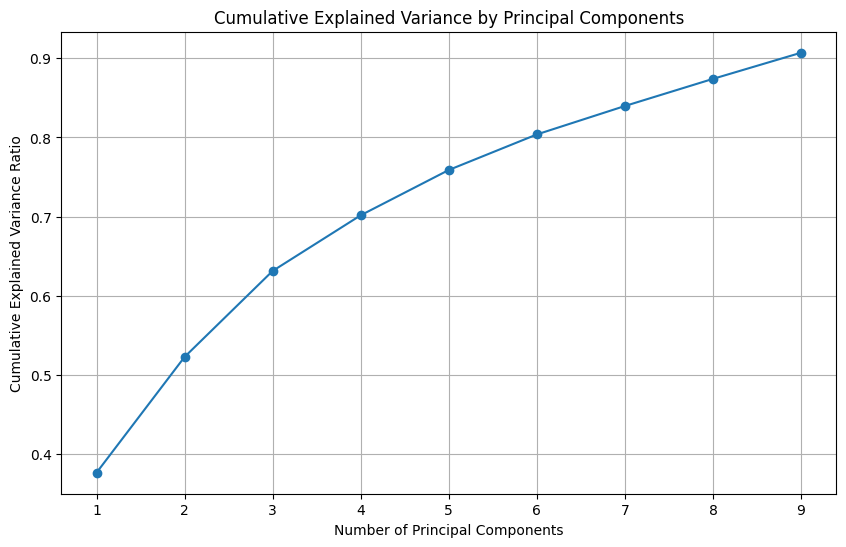

Explained variance ratio per component: [0.37651575 0.14623063 0.10860679 0.07030069 0.05720113 0.04490965
 0.03591913 0.03425908 0.03302093]
Cumulative explained variance: [0.37651575 0.52274639 0.63135318 0.70165387 0.75885499 0.80376464
 0.83968377 0.87394285 0.90696378]


In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("clinvar_set_VEPs.csv")
cols = [
    # Ensemble predictors
    "CADD", "REVEL", "MetaSVM", "MetaLR",
    "DEOGEN2", "PrimateAI", "DANN",

    # Conservation
    "phyloP", "phastCons", "GERP++",

    # Protein impact
    "SIFT", "SIFT4G",
    "Polyphen2_HumDiv", "Polyphen2_HumVar",
    "MutationAssessor"
]

df_clust = df[cols].copy()
df_clust.describe()

from sklearn.preprocessing import StandardScaler

df_clust_cleaned = df_clust.dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust_cleaned)
from sklearn.decomposition import PCA
pca=PCA(n_components=0.90)
X_pca=pca.fit_transform(X_scaled)
print("PCA components retained:",X_pca.shape[1])

import matplotlib.pyplot as plt

explained_var = pca.explained_variance_ratio_
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(explained_var) + 1), np.cumsum(explained_var), marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.xticks(np.arange(1, len(explained_var) + 1))
plt.show()

print(f"Explained variance ratio per component: {explained_var}")
print(f"Cumulative explained variance: {np.cumsum(explained_var)}")

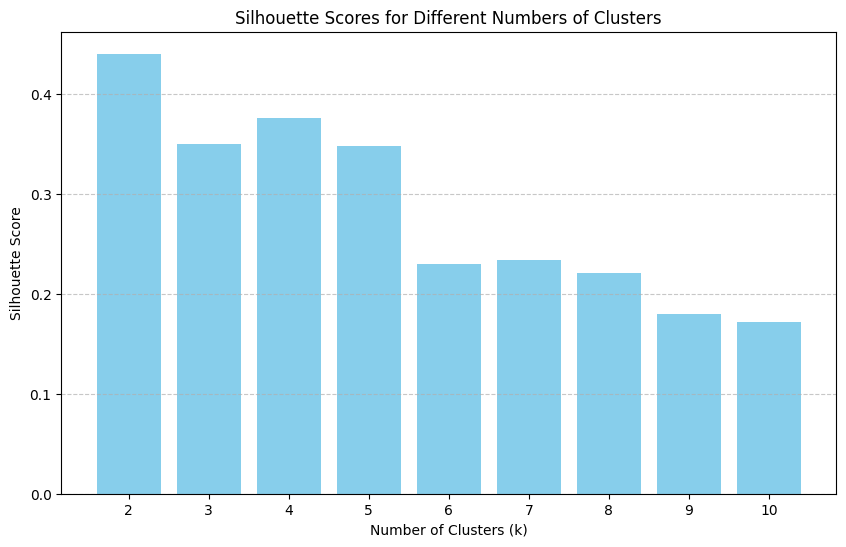

Optimal clusters: 2
Cluster assignment successful.
Cluster
1    12434
0     3173
Name: count, dtype: int64


/tmp/ipython-input-252112129.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clust_cleaned["Cluster"] = kmeans.fit_predict(X_pca)


,CADD,REVEL,MetaSVM,MetaLR,DEOGEN2,PrimateAI,DANN,phyloP,phastCons,GERP++,SIFT,SIFT4G,Polyphen2_HumDiv,Polyphen2_HumVar,MutationAssessor
Cluster,,,,,,,,,,,,,,,
0,24.151,0.531,-0.123,0.471,0.554,0.658,0.971,4.941,0.870,3.957,0.075,0.145,0.625,0.520,1.901
1,28.192,0.877,0.860,0.865,0.854,0.752,0.995,7.157,0.989,4.911,0.004,0.014,0.970,0.941,3.341


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_pca)
    sil[k] = silhouette_score(X_pca, labels)

sil
import matplotlib.pyplot as plt

k_values = list(sil.keys())
silhouette_scores = list(sil.values())

plt.figure(figsize=(10, 6))
plt.bar(k_values, silhouette_scores, color='skyblue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different Numbers of Clusters')
plt.xticks(k_values)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
optimal_k = max(sil, key=sil.get)
print("Optimal clusters:", optimal_k)

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)

df_clust_cleaned["Cluster"] = kmeans.fit_predict(X_pca)

print("Cluster assignment successful.")
print(df_clust_cleaned["Cluster"].value_counts())
cluster_summary = df_clust_cleaned.groupby("Cluster").mean().round(3)
cluster_summary

              CADD     REVEL   MetaSVM    GERP++    phyloP
Cluster                                                   
0        24.151295  0.530763 -0.122520  3.956620  4.941229
1        28.192326  0.877467  0.860371  4.911013  7.156693


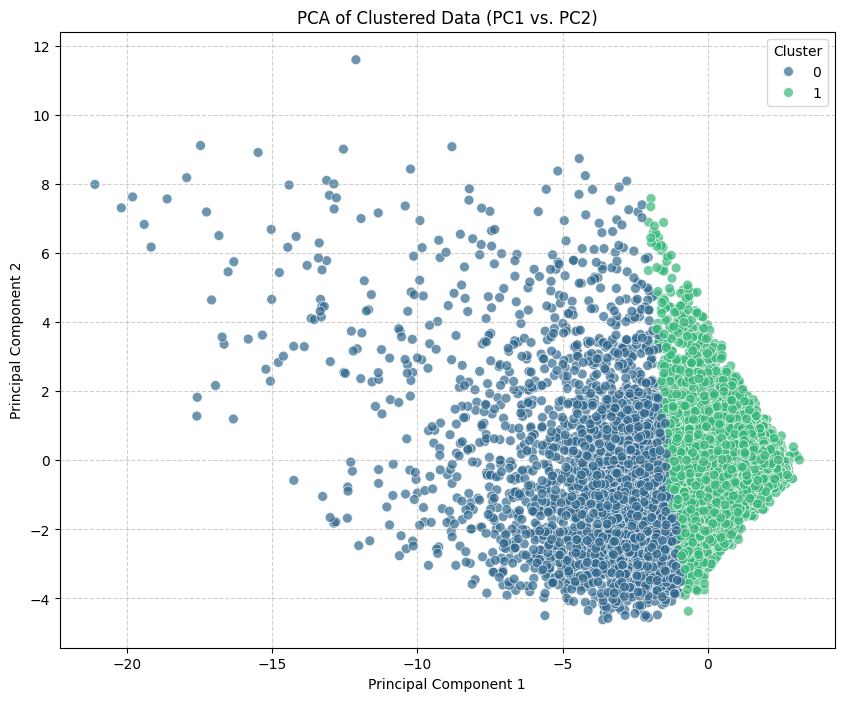

In [ ]:
profile_cols1_pca_components = ["CADD","REVEL","MetaSVM","GERP++","phyloP"]

cluster_profile1 = df_clust_cleaned.groupby("Cluster")[profile_cols1_pca_components].mean()
print(cluster_profile1)
import pandas as pd
import numpy as np

from sklearn.cluster import (
    KMeans, AgglomerativeClustering, SpectralClustering, DBSCAN
)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score
)

results = []

# ---------- KMeans ----------
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
labels_km = kmeans.fit_predict(X_pca)

results.append({
    "Model": "KMeans",
    "Silhouette": silhouette_score(X_pca, labels_km),
    "Calinski-Harabasz": calinski_harabasz_score(X_pca, labels_km),
    "Davies-Bouldin": davies_bouldin_score(X_pca, labels_km)
})

# ---------- Gaussian Mixture ----------
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
labels_gmm = gmm.fit_predict(X_pca)

results.append({
    "Model": "GMM",
    "Silhouette": silhouette_score(X_pca, labels_gmm),
    "Calinski-Harabasz": calinski_harabasz_score(X_pca, labels_gmm),
    "Davies-Bouldin": davies_bouldin_score(X_pca, labels_gmm)
})

# ---------- Agglomerative ----------
agg = AgglomerativeClustering(n_clusters=optimal_k, linkage="ward")
labels_agg = agg.fit_predict(X_pca)

results.append({
    "Model": "Agglomerative (Ward)",
    "Silhouette": silhouette_score(X_pca, labels_agg),
    "Calinski-Harabasz": calinski_harabasz_score(X_pca, labels_agg),
    "Davies-Bouldin": davies_bouldin_score(X_pca, labels_agg)
})

# ---------- Spectral ----------
spec = SpectralClustering(
    n_clusters=optimal_k,
    affinity="nearest_neighbors",
    random_state=42
)
labels_spec = spec.fit_predict(X_pca)

results.append({
    "Model": "Spectral",
    "Silhouette": silhouette_score(X_pca, labels_spec),
    "Calinski-Harabasz": calinski_harabasz_score(X_pca, labels_spec),
    "Davies-Bouldin": davies_bouldin_score(X_pca, labels_spec)
})
df_results = pd.DataFrame(results)
df_results
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for plotting
plot_df = pd.DataFrame(X_pca[:, :2], columns=['PC1', 'PC2'])
plot_df['Cluster'] = df_clust_cleaned['Cluster'].values

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster', data=plot_df,
    palette='viridis', legend='full', s=50, alpha=0.7
)
plt.title('PCA of Clustered Data (PC1 vs. PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X = df_clust_cleaned.drop('Cluster', axis=1)
y = df_clust_cleaned['Cluster']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (12485, 15)
X_test shape: (3122, 15)
y_train shape: (12485,)
y_test shape: (3122,)


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       638
           1       0.99      1.00      0.99      2484

    accuracy                           0.99      3122
   macro avg       0.99      0.98      0.98      3122
weighted avg       0.99      0.99      0.99      3122



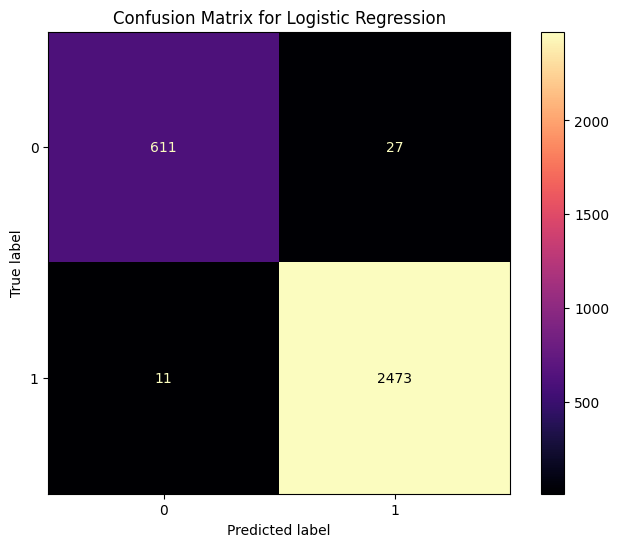

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')

log_reg_model.fit(X_train, y_train)
y_pred_log_reg = log_reg_model.predict(X_test)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_reg))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_log_reg = confusion_matrix(y_test, y_pred_log_reg, labels=log_reg_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=log_reg_model.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='magma', ax=ax, values_format='d')
plt.title('Confusion Matrix for Logistic Regression')
plt.grid(False)
plt.show()

Decision Tree Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       638
           1       0.97      0.97      0.97      2484

    accuracy                           0.96      3122
   macro avg       0.93      0.93      0.93      3122
weighted avg       0.96      0.96      0.96      3122



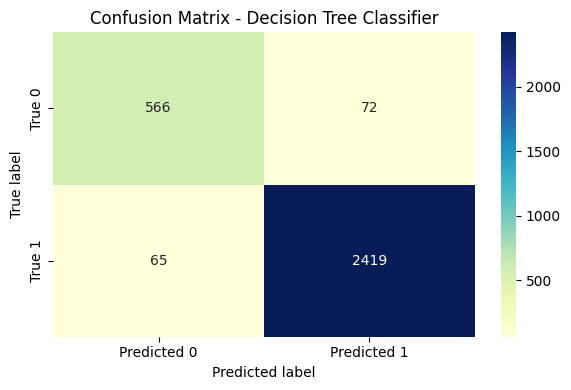

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Classifier Classification Report:")
print(classification_report(y_test, y_pred_dt))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['True 0', 'True 1'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.tight_layout()
plt.show()



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Classifier Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       638
           1       0.98      0.99      0.99      2484

    accuracy                           0.98      3122
   macro avg       0.98      0.96      0.97      3122
weighted avg       0.98      0.98      0.98      3122



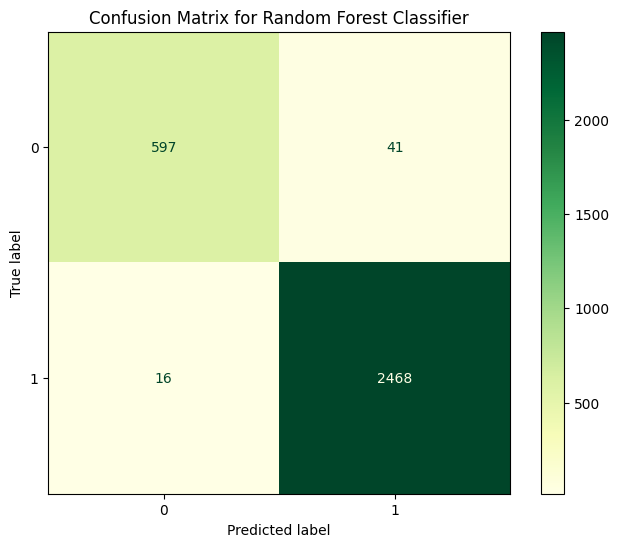

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf_model.classes_)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='YlGn', ax=ax, values_format='d')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.grid(False) # Remove grid lines as they can clutter confusion matrix plots
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:07:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       638
           1       0.99      0.99      0.99      2484

    accuracy                           0.98      3122
   macro avg       0.98      0.97      0.98      3122
weighted avg       0.98      0.98      0.98      3122



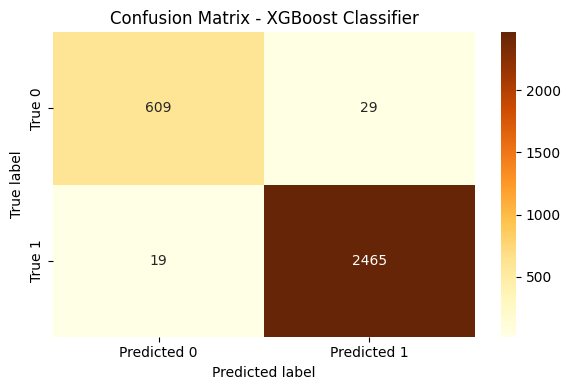

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss') # use_label_encoder and eval_metric are set to suppress warnings
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Classifier Classification Report:")
print(classification_report(y_test, y_pred_xgb))
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['True 0', 'True 1'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix - XGBoost Classifier')
plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.4 MB/s eta 0:00:00
CatBoost Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       638
           1       0.99      0.99      0.99      2484

    accuracy                           0.99      3122
   macro avg       0.98      0.98      0.98      3122
weighted avg       0.99      0.99      0.99      3122



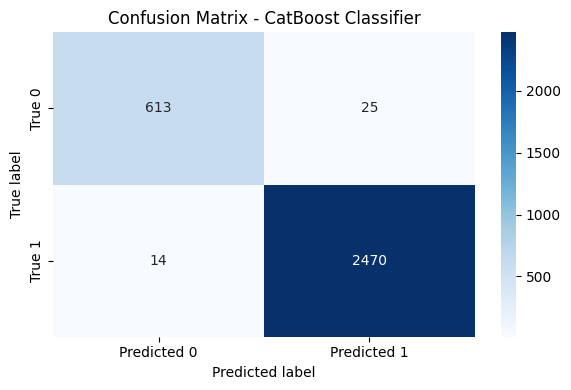

In [ ]:
import sys
!{sys.executable} -m pip install catboost
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

cb_model = CatBoostClassifier(random_state=42, verbose=False)
cb_model.fit(X_train, y_train)
y_pred_catboost = cb_model.predict(X_test)

print("CatBoost Classifier Classification Report:")
print(classification_report(y_test, y_pred_catboost))

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_catboost)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='inferno',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['True 0', 'True 1'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix - CatBoost Classifier')
plt.tight_layout()
plt.show()


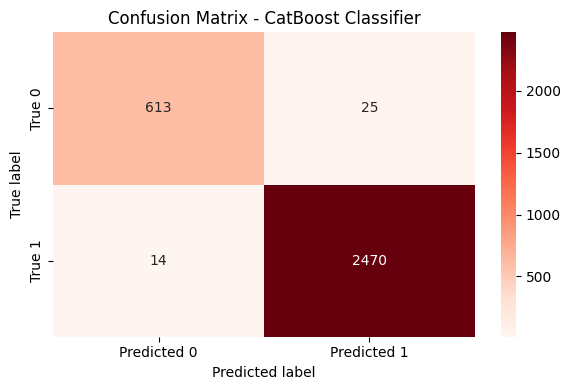

In [ ]:
cm = confusion_matrix(y_test, y_pred_catboost)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['True 0', 'True 1'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix - CatBoost Classifier')
plt.tight_layout()
plt.show()

AdaBoost Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       638
           1       0.98      0.98      0.98      2484

    accuracy                           0.97      3122
   macro avg       0.95      0.95      0.95      3122
weighted avg       0.97      0.97      0.97      3122



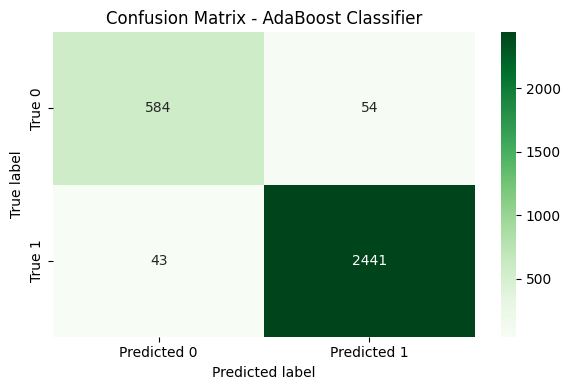

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report

adaboost_model = AdaBoostClassifier(random_state=42)
adaboost_model.fit(X_train, y_train)
y_pred_adaboost = adaboost_model.predict(X_test)

print("AdaBoost Classifier Classification Report:")
print(classification_report(y_test, y_pred_adaboost))
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_adaboost)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['True 0', 'True 1'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix - AdaBoost Classifier')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
ann_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
ann_model.fit(X_train, y_train)
y_pred_ann = ann_model.predict(X_test)
print("ANN Classifier Classification Report:")
print(classification_report(y_test, y_pred_ann))

ANN Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       638
           1       0.99      0.99      0.99      2484

    accuracy                           0.99      3122
   macro avg       0.99      0.99      0.99      3122
weighted avg       0.99      0.99      0.99      3122



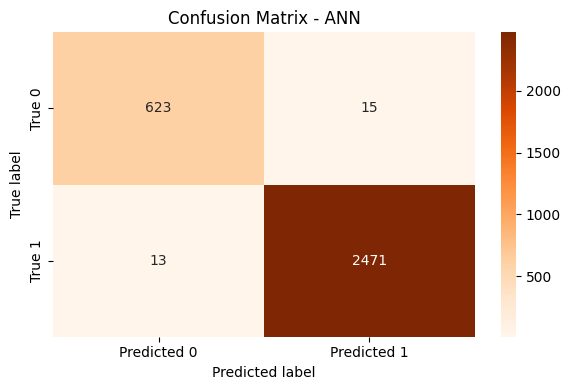

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_ann)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['True 0', 'True 1'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix - ANN')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("SVM Classifier Classification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       638
           1       1.00      1.00      1.00      2484

    accuracy                           1.00      3122
   macro avg       0.99      0.99      0.99      3122
weighted avg       1.00      1.00      1.00      3122



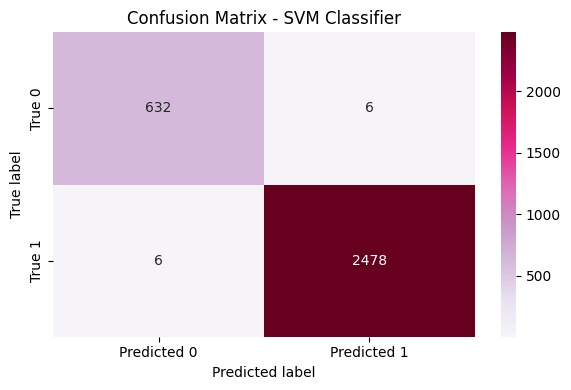

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['True 0', 'True 1'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix - SVM Classifier')
plt.tight_layout()
plt.show()


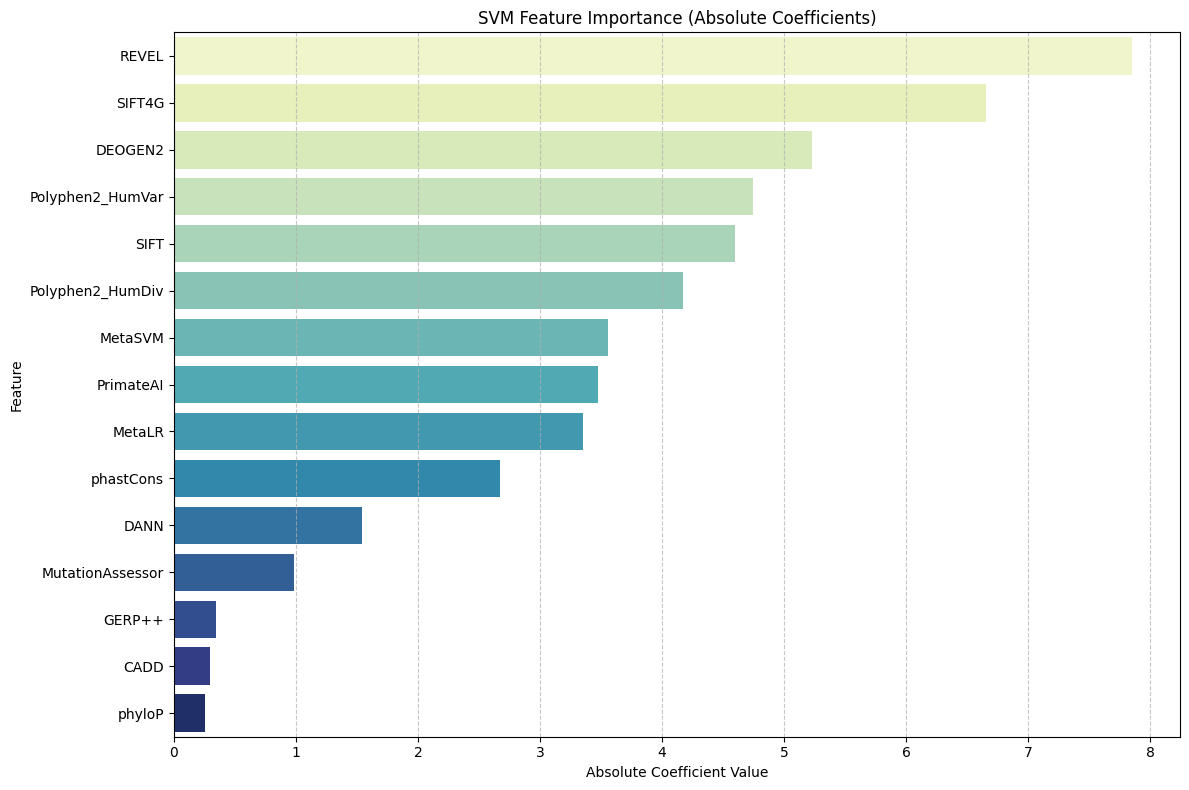

In [ ]:
if 'feature_importance_svm' not in locals() and 'feature_importance_svm' not in globals():
    svm_coefficients = svm_model.coef_[0]
    feature_names = X_train.columns

    feature_importance_svm = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': svm_coefficients
    })
    feature_importance_svm['Absolute_Coefficient'] = abs(feature_importance_svm['Coefficient'])

feature_importance_svm_sorted = feature_importance_svm.sort_values(by='Absolute_Coefficient', ascending=False)

N_features = len(feature_importance_svm_sorted)

plt.figure(figsize=(12, 8))
sns.barplot(x='Absolute_Coefficient', y='Feature', hue='Feature', data=feature_importance_svm_sorted.head(N_features), palette='YlGnBu', legend=False)
plt.title('SVM Feature Importance (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

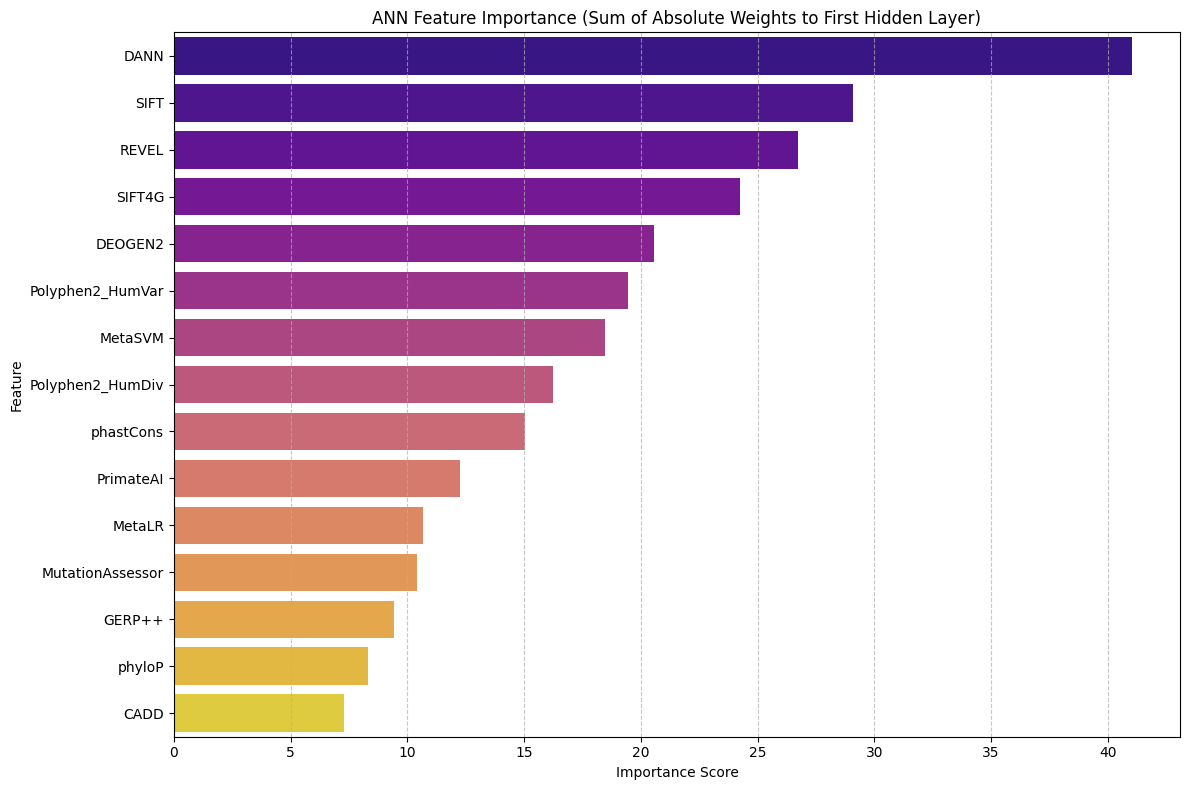

In [ ]:
input_to_hidden_weights = ann_model.coefs_[0]
ann_feature_importances = pd.Series(
    np.sum(np.abs(input_to_hidden_weights), axis=1),
    index=X_train.columns,
    name='ANN_Feature_Importance'
)

# Sort the importances in descending order
ann_feature_importances = ann_feature_importances.sort_values(ascending=False)

# Create the bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x=ann_feature_importances.values, y=ann_feature_importances.index, hue=ann_feature_importances.index, palette='plasma', legend=False)
plt.title('ANN Feature Importance (Sum of Absolute Weights to First Hidden Layer)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()